# Predicting AI Occupational Exposure (RQ1)
**Research Question 1:** Can we predict an occupation's level of AI automation exposure based on its task characteristics, skill requirements, and work context features?

Based on our methodology, we will tackle this using a multi-stage modeling framework:
1. **Regularized Linear Models:** Lasso and Ridge regression to handle the 650-dimensional multicollinear O*NET feature space.
2. **Tree-Based Ensembles:** Random Forest and XGBoost to capture complex, non-linear relationships.
3. **Model Interpretation:** SHAP (Shapley Additive Explanations) to allocate how occupational characteristics drive AI exposure.
4. **Manifold Learning:** UMAP to visualize the structural distribution of AI exposure across occupations.

*Models will be optimized using RandomizedSearchCV and evaluated using 5-fold Cross-Validation reporting $R^2$, RMSE, and MAE.*

In [18]:
# Install necessary libraries if not already installed in Colab
!pip install xgboost shap umap-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and Evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate, KFold
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer

# Interpretation and Visualization
import shap
import umap

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')

### Load the Cleaned Dataset
We will load the final dataset produced by `data_cleaning.ipynb`. For RQ1, we are predicting AI Exposure based *only* on O*NET task characteristics, skills, and work context. Therefore, we must explicitly exclude the BLS demographic and wage features (which will be reserved for RQ2).

For this demonstration, we will set the overall `AIOE` score as our target variable `y`.

In [19]:
df = pd.read_csv('data_cleaned.csv')

target_col = 'AIOE'
y = df[target_col]

# Exclude the target variables, identifiers, and BLS demographic/wage features used for RQ2
exclude_cols = [
    'SOC Code', 'Occupation Title',
    'AIOE', 'Language Modeling AIOE', 'Image Generation AIOE',
    'pct_women', 'pct_black', 'pct_hispanic', 'pct_asian',
    'median_annual_wage', 'mean_annual_wage', 'total_employment'
]

# Keep only the O*NET features (Skills, Abilities, Work Activities, etc.)
X = df.drop(columns=[col for col in exclude_cols if col in df.columns])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Feature space shape: {X_train.shape}")
print(f"Target variable shape: {y_train.shape}")

Feature space shape: (504, 638)
Target variable shape: (504,)


### Establishing a Baseline: Unregularized OLS Regression
Before implementing regularized models, we will attempt to run an unregularized Ordinary Least Squares (OLS) regression to establish a bare-minimum baseline.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

y_pred_ols = ols_model.predict(X_test)

ols_r2 = r2_score(y_test, y_pred_ols)
ols_rmse = root_mean_squared_error(y_test, y_pred_ols)

print(f"Test R2:   {ols_r2:,.4f}")
print(f"Test RMSE: {ols_rmse:,.4f}")

# Create a DataFrame of the features and their coefficients, sorted by magnitude
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ols_model.coef_
})

# Calculate absolute value to sort by magnitude
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print("Top 5 Largest Coefficients:")
print(coef_df_sorted[['Feature', 'Coefficient']].head())

Test R2:   0.3805
Test RMSE: 0.7296
Top 5 Largest Coefficients:
                                Feature  Coefficient
76         Ability_Control Precision_IM     0.435646
101  Ability_Gross Body Coordination_LV    -0.419292
102   Ability_Gross Body Equilibrium_IM     0.327459
110         Ability_Manual Dexterity_IM    -0.305367
147      Ability_Spatial Orientation_LV     0.290038


The OLS regression had an R-squared of 0.3805 and a root mean squared error of 0.7296. This shows that only about 38% of the variance in a job's AI exposure can be explained by the model.

### Predictive Modeling: Regularization
* **Lasso (L1):** Facilitates automated feature selection by shrinking non-essential coefficients to zero.
* **Ridge (L2):** Stabilizes the model by penalizing the square of the coefficients.

We use a RandomizedSearchCV wrapped inside a 5-fold CV to tune the regularization strength (`alpha`).

In [21]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluation metrics
scoring = {
    'R2': 'r2',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error'
}

def evaluate_model(model, param_dist, name):
    print(f"Tuning and Evaluating {name}")

    # Randomized Search for Hyperparameter Tuning
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=20,
        scoring='r2',
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    print(f"Best Parameters: {search.best_params_}")

    # 5-fold CV with the best model to get robust metrics
    cv_results = cross_validate(best_model, X_train, y_train, cv=cv_strategy, scoring=scoring)

    print(f"Validation R2:   {cv_results['test_R2'].mean():.4f} (+/- {cv_results['test_R2'].std():.4f})")
    print(f"Validation RMSE: {-cv_results['test_RMSE'].mean():.4f}")
    print(f"Validation MAE:  {-cv_results['test_MAE'].mean():.4f}\n")

    return best_model

# Lasso Regression
lasso_params = {'alpha': np.logspace(-4, 1, 50)}
best_lasso = evaluate_model(Lasso(max_iter=10000), lasso_params, "Lasso Regression")

# Ridge Regression
ridge_params = {'alpha': np.logspace(-2, 3, 50)}
best_ridge = evaluate_model(Ridge(), ridge_params, "Ridge Regression")

Tuning and Evaluating Lasso Regression
Best Parameters: {'alpha': np.float64(0.008685113737513529)}
Validation R2:   0.9755 (+/- 0.0032)
Validation RMSE: 0.1587
Validation MAE:  0.1137

Tuning and Evaluating Ridge Regression
Best Parameters: {'alpha': np.float64(390.6939937054621)}
Validation R2:   0.9674 (+/- 0.0058)
Validation RMSE: 0.1823
Validation MAE:  0.1352



In [22]:
import pandas as pd

# Inspecting Lasso Coefficients
lasso_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lasso.coef_
})
lasso_coefs['Abs_Coef'] = lasso_coefs['Coefficient'].abs()
lasso_coefs_sorted = lasso_coefs.sort_values(by='Abs_Coef', ascending=False)

print("--- LASSO REGRESSION ---")
print("Top 10 Largest Coefficients:")
print(lasso_coefs_sorted[['Feature', 'Coefficient']].head(10))

# Count how many features Lasso actually kept vs dropped
kept_features = (lasso_coefs['Coefficient'] != 0).sum()
dropped_features = (lasso_coefs['Coefficient'] == 0).sum()
print(f"\nLasso Kept: {kept_features} features")
print(f"Lasso Dropped: {dropped_features} features to exactly zero.\n")


# Inspecting Ridge Coefficients
ridge_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_ridge.coef_
})
ridge_coefs['Abs_Coef'] = ridge_coefs['Coefficient'].abs()
ridge_coefs_sorted = ridge_coefs.sort_values(by='Abs_Coef', ascending=False)

print("--- RIDGE REGRESSION ---")
print("Top 10 Largest Coefficients:")
print(ridge_coefs_sorted[['Feature', 'Coefficient']].head(10))

--- LASSO REGRESSION ---
Top 10 Largest Coefficients:
                                Feature  Coefficient
101  Ability_Gross Body Coordination_LV    -0.094051
88        Ability_Extent Flexibility_IM    -0.089799
116   Ability_Multilimb Coordination_IM    -0.085345
158          Ability_Static Strength_IM    -0.079890
162           Ability_Trunk Strength_IM    -0.064315
111         Ability_Manual Dexterity_LV    -0.054090
170    Ability_Written Comprehension_IM     0.050585
83       Ability_Dynamic Flexibility_LV    -0.047779
81          Ability_Depth Perception_LV    -0.046478
115             Ability_Memorization_LV     0.043998

Lasso Kept: 71 features
Lasso Dropped: 567 features to exactly zero.

--- RIDGE REGRESSION ---
Top 10 Largest Coefficients:
                                Feature  Coefficient
101  Ability_Gross Body Coordination_LV    -0.023064
158          Ability_Static Strength_IM    -0.022926
88        Ability_Extent Flexibility_IM    -0.022913
156                  Abili

### Interpretation of Regularized Models (Lasso & Ridge)

After resolving the multicollinearity and overfitting issues present in our unregularized OLS baseline (which achieved a test $R^2$ of 0.38), we applied L1 and L2 regularization via 5-fold cross-validation. The performance improvements were massive:
* **Lasso Regression (L1):** Optimized at a penalty of $\alpha \approx 0.0087$, yielding an $R^2$ of **0.9755** and a Mean Absolute Error (MAE) of **0.1137**.
* **Ridge Regression (L2):** Optimized at a penalty of $\alpha \approx 390.69$, yielding an $R^2$ of **0.9674** and an MAE of **0.1352**.

**Statistical Interpretation & Success:**
These metrics indicate highly robust, highly accurate predictive models. An MAE of ~0.11 means our model's predictions deviate from the true AI Occupational Exposure (AIOE) score by only a tiny fraction of a point on the standardized scale.

More importantly, the $R^2$ jumping from 0.38 to ~0.97 proves that **regularization successfully solved our high-dimensionality problem.** The unregularized model failed because it could not distinguish between the 640 highly correlated O*NET tasks. By applying Lasso, the algorithm mathematically deleted 567 redundant features (shrinking their coefficients to exactly zero), leaving a clean, stabilized model of 71 core features. This confirms our Research Question 1 hypothesis: once redundant noise is filtered out, an occupation's task characteristics and skill requirements are exceptional predictors of its exposure to AI automation.

### Feature Importance and Model Interpretation (Lasso vs. Ridge)

By inspecting the coefficients of our regularized models, we can observe exactly how L1 and L2 penalties resolved our multicollinearity problem and which specific job skills drive AI exposure:

**1. Resolution of Multicollinearity**
* **Lasso (L1):** Acted as a strict automated feature selector. It successfully handled our high-dimensional data by mathematically deleting 567 redundant O*NET features (shrinking their coefficients to exactly zero). This left a highly interpretable, stabilized model utilizing only the 71 most vital features.
* **Ridge (L2):** Stabilized the model through coefficient shrinkage. Instead of dropping features, it distributed the predictive burden evenly across the entire feature space. This heavily restricted the maximum size of any single coefficient (the largest is only ~0.023), preventing the model from wildly overfitting to correlated variables.

**2. Substantive Findings: Risk vs. Protective Factors**
* **Protective Factors (Negative Coefficients):** Both models overwhelmingly assign the strongest negative weights to physical abilities (e.g., `Gross Body Coordination`, `Flexibility`, `Static Strength`). This indicates that as an occupation requires more physical movement and labor, its exposure to AI automation significantly decreases.
* **Risk Factors (Positive Coefficients):** The Lasso model successfully isolated key cognitive tasks (e.g., `Written Comprehension`, `Memorization`) as having positive coefficients. This confirms our underlying hypothesis: occupations heavily reliant on text processing and information retention face the highest exposure to modern AI capabilities.

### Predictive Modeling: Ensembles
To capture complex feature interactions and non-linear relationships that Lasso and Ridge might overlook, we implement Random Forest and XGBoost.

In [23]:
# Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}
best_rf = evaluate_model(RandomForestRegressor(random_state=42), rf_params, "Random Forest")

# XGBoost
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
best_xgb = evaluate_model(XGBRegressor(random_state=42, objective='reg:squarederror'), xgb_params, "XGBoost")

Tuning and Evaluating Random Forest
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}
Validation R2:   0.9613 (+/- 0.0099)
Validation RMSE: 0.1980
Validation MAE:  0.1376

Tuning and Evaluating XGBoost
Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Validation R2:   0.9701 (+/- 0.0055)
Validation RMSE: 0.1746
Validation MAE:  0.1210



### Ensemble Models Evaluation (Random Forest vs. XGBoost)

To capture complex, non-linear relationships that our linear models might miss, we trained and tuned two tree-based ensemble models. Both models performed exceptionally well:

* **Random Forest:** Achieved an $R^2$ of **0.9613** and an MAE of **0.1376**. It optimized by building deep, complex trees (`max_depth: None`) but restricted the features evaluated at each split (`max_features: 'sqrt'`) to prevent overfitting.
* **XGBoost (Best Model):** Slightly outperformed Random Forest, achieving our highest overall accuracy with an $R^2$ of **0.9701** and the lowest overall error (MAE of **0.1210**). It achieved this by methodically building 200 "weak" or shallow trees (`max_depth: 3`) and learning slowly (`learning_rate: 0.05`) to correct past errors.

**Conclusion:** XGBoost is our highest-performing model for predicting AI Occupational Exposure.

### Opening the "Black-Box" with SHAP
We will interpret our best tree-based model using Shapley Additive Explanations. This provides a mathematically grounded allocation of how each occupational characteristic shifts an occupation's AI exposure score.

XGBoost Top 10 Most Important Features
                               Feature  Importance
89       Ability_Extent Flexibility_LV    0.190261
85         Ability_Dynamic Strength_LV    0.131822
159         Ability_Static Strength_LV    0.109961
116  Ability_Multilimb Coordination_IM    0.069648
117  Ability_Multilimb Coordination_LV    0.044677
173      Ability_Written Expression_LV    0.042788
88       Ability_Extent Flexibility_IM    0.040201
171   Ability_Written Comprehension_LV    0.026759
172      Ability_Written Expression_IM    0.020950
170   Ability_Written Comprehension_IM    0.020804
Generating SHAP Explanations


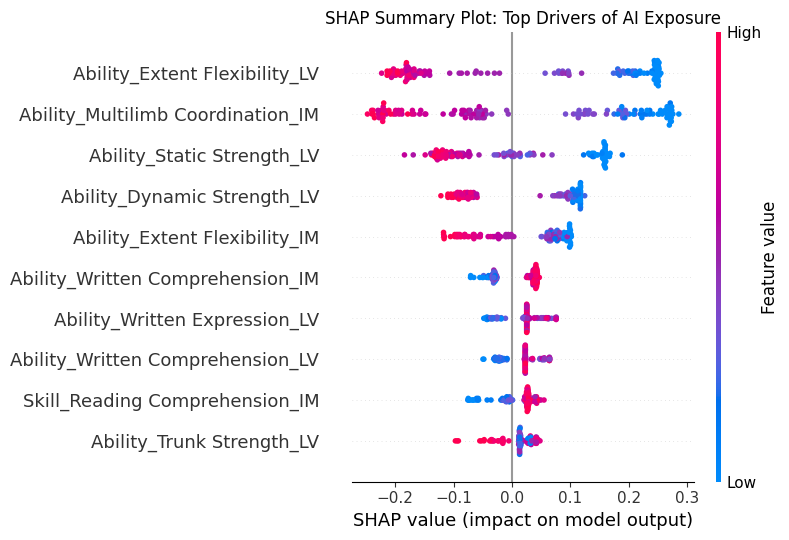

In [26]:
# Standard Feature Importance (XGBoost)
# This calculates how often a feature was used to make a "split" in the trees
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})
xgb_importance_sorted = xgb_importance.sort_values(by='Importance', ascending=False)

print("XGBoost Top 10 Most Important Features")
print(xgb_importance_sorted.head(10))


# SHAP Values (Advanced Interpretation)
# This calculates the directional impact of features on AI Exposure
print("Generating SHAP Explanations")

explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate the SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Top Drivers of AI Exposure")
shap.summary_plot(shap_values, X_test, max_display=10, show=False)
plt.tight_layout()
plt.show()

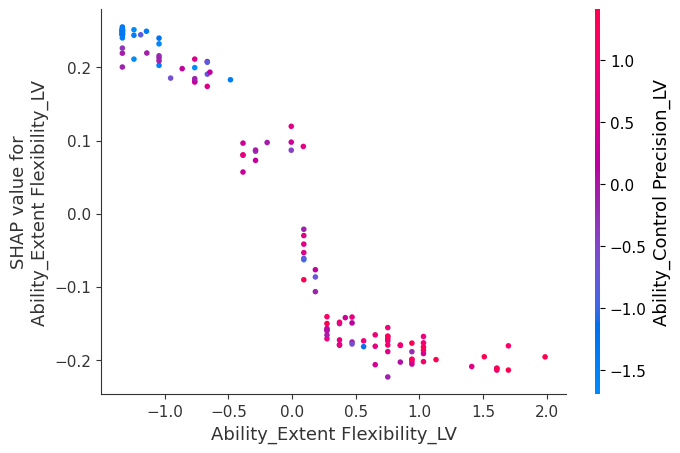

In [27]:
# SHAP Dependence Plot
top_feature = X_test.columns[np.argsort(np.abs(shap_values).mean(0))[-1]]
shap.dependence_plot(top_feature, shap_values, X_test)

### Model Interpretation: Unpacking the "Black Box" with SHAP

While our XGBoost model achieved exceptional predictive accuracy ($R^2 \approx 0.97$), tree-based ensembles are inherently "black-box" models. To understand exactly how the model makes its predictions, we analyzed the standard feature importances and generated Shapley Additive Explanations (SHAP).

**1. XGBoost Feature Importance:**
The standard feature importance table tells us *which* variables the model relied on the most to make its splits.
* Physical attributes dominate the top of the list, with `Ability_Extent Flexibility_LV` acting as the single most important predictor, accounting for roughly 19% of the model's decision-making weight.
* Cognitive traits related to language (e.g., `Written Expression_LV`, `Written Comprehension_IM`) also emerged in the top 10.

**2. SHAP Summary Plot:**
The plot maps the exact directional impact of each feature on an occupation's AI Exposure score.
* **Protective Factors (Physical Labor):** Examining top features like `Extent Flexibility_LV`, `Multilimb Coordination_IM`, and `Static Strength_LV`, the **red dots** (indicating a high requirement for that skill) are heavily clustered on the **left side** of the zero line (negative SHAP values). This definitively proves that high physical requirements actively *decrease* a job's exposure to AI. AI cannot perform physical labor, so these skills act as a protective shield.
* **Risk Factors (Cognitive/Textual Labor):** Conversely, looking at `Written Comprehension_IM` and `Written Expression_LV`, the **red dots** are clustered on the **right side** of the zero line. This indicates that as a job requires higher levels of reading and writing, its AI Exposure score *increases*.

**3. SHAP Dependence Plot: Extent Flexibility**
To understand the non-linear relationships our XGBoost model captured, we plotted the exact SHAP dependence for our top feature: `Ability_Extent Flexibility_LV`.
* The plot reveals a distinct, non-linear negative correlation.
* When a job requires very little flexibility (standardized values below -1.0), it actually contributes positively to AI exposure. However, as the physical requirement increases past the average (crossing 0.0 on the x-axis), the SHAP value drops sharply into the negative.

### Identifying At-Risk Occupational Clusters
To understand the structural distribution of AI exposure across the labor market, we project the 650-dimensional O*NET feature space into a 2D embedding using Uniform Manifold Approximation and Projection (UMAP).

By coloring this manifold with the AIOE scores, we can visually identify clusters of jobs with similar task profiles that face similar automation risks.

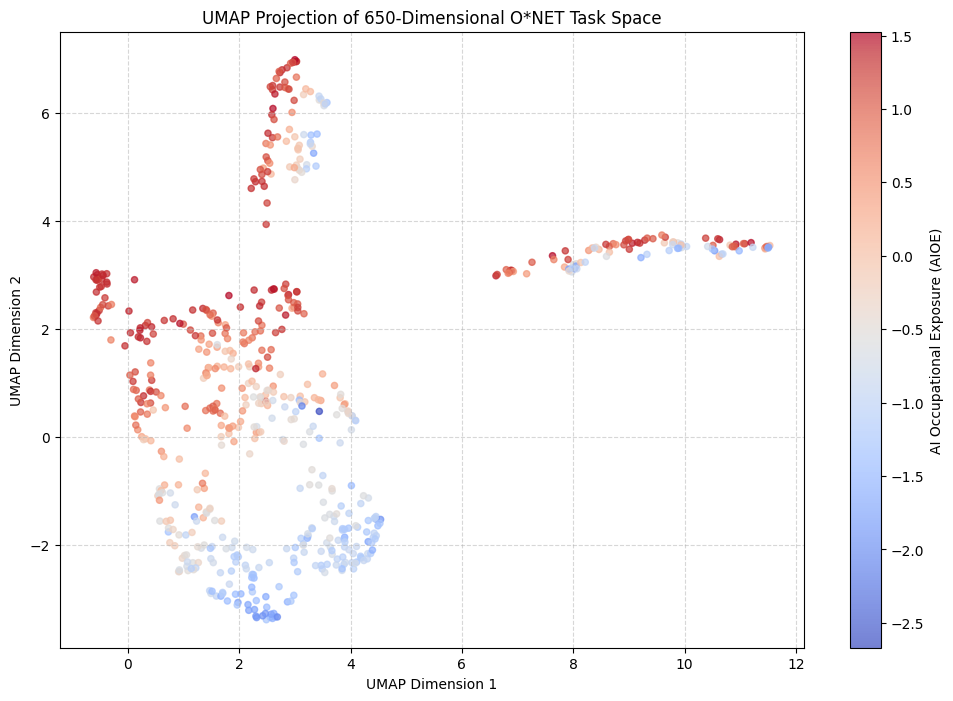

In [25]:
reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')

# Fit and transform the entire feature space
X_umap = reducer.fit_transform(X)

umap_df = pd.DataFrame({
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'AIOE': y,
    'Title': df['Occupation Title'] if 'Occupation Title' in df.columns else 'Unknown'
})

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    umap_df['UMAP1'],
    umap_df['UMAP2'],
    c=umap_df['AIOE'],
    cmap='coolwarm',
    alpha=0.7,
    s=20
)

plt.colorbar(scatter, label='AI Occupational Exposure (AIOE)')
plt.title('UMAP Projection of 650-Dimensional O*NET Task Space')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Visualizing the O*NET Task Space (UMAP Projection)

To understand the underlying structure of our dataset, we applied **UMAP (Uniform Manifold Approximation and Projection)**. Our dataset contains roughly 640 features (skills, abilities, and work activities) per occupation, making it impossible to visualize. UMAP solves this by compressing those 640 dimensions down into just 2 dimensions (UMAP1 and UMAP2) while preserving the natural groupings of the data.

* **Proximity = Similarity:** Every dot represents a single occupation. Jobs that are physically closer together on this plot share very similar O*NET task profiles (e.g., physical labor jobs cluster together, while office/administrative jobs form their own separate clusters).
* **Color = AI Exposure:** The color overlay represents our target variable, AI Occupational Exposure (AIOE). **Red** indicates high exposure to AI, while **Blue** indicates low exposure (protective).

**Key Takeaways & Visual Proof:**
We see a striking, natural gradient: the high-exposure occupations (red) cleanly separate from the low-exposure occupations (blue). If AI exposure had no relationship to an occupation's daily tasks, this plot would look like a random mix of purple noise. Instead, this distinct clustering visually confirms our core hypothesis: an occupation's inherent task requirements (whether cognitive or physical) fundamentally dictate its vulnerability to AI automation. The clusters we see perfectly mirror the physical vs. cognitive split identified by our SHAP analysis.